<a href="https://colab.research.google.com/github/JakeOh/202605_BD57/blob/main/lab_ml/ml08_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Logistic Regression**

(주의) **분류** 알고리즘

# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression  # 분류 모델
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report

# Fish 데이터셋

물고기의 모든 특성(무게, 길이, 대각선, 키, 두께)을 사용한 물고기 종류(Bream vs Smelt) 이진 분류

In [2]:
file_path = 'https://bit.ly/fish_csv_data'

In [3]:
fish = pd.read_csv(file_path)

In [4]:
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [5]:
df = fish[fish.Species.isin(['Bream', 'Smelt'])]

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49 entries, 0 to 158
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Species   49 non-null     object 
 1   Weight    49 non-null     float64
 2   Length    49 non-null     float64
 3   Diagonal  49 non-null     float64
 4   Height    49 non-null     float64
 5   Width     49 non-null     float64
dtypes: float64(5), object(1)
memory usage: 2.7+ KB


In [7]:
df.Species.value_counts()

,count
Species,
Bream,35
Smelt,14


In [8]:
x = df[df.columns[1:]].values  # 특성(features)
y = df.Species.values  # 타겟(target)

In [9]:
x[:5]

array([[242.    ,  25.4   ,  30.    ,  11.52  ,   4.02  ],
       [290.    ,  26.3   ,  31.2   ,  12.48  ,   4.3056],
       [340.    ,  26.5   ,  31.1   ,  12.3778,   4.6961],
       [363.    ,  29.    ,  33.5   ,  12.73  ,   4.4555],
       [430.    ,  29.    ,  34.    ,  12.444 ,   5.134 ]])

In [10]:
y[:5]

array(['Bream', 'Bream', 'Bream', 'Bream', 'Bream'], dtype=object)

# 훈련 셋 vs 테스트 셋 나누기

In [11]:
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size=0.25,
                                                    random_state=42,
                                                    stratify=y)  # 층화 추출

In [12]:
x_train.shape

(36, 5)

In [14]:
x_test.shape

(13, 5)

In [18]:
x_train[:5]

array([[720.    ,  35.    ,  40.6   ,  16.3618,   6.09  ],
       [363.    ,  29.    ,  33.5   ,  12.73  ,   4.4555],
       [  8.7   ,  11.3   ,  12.6   ,   1.9782,   1.2852],
       [500.    ,  30.7   ,  36.2   ,  14.2266,   4.9594],
       [  9.8   ,  11.2   ,  12.4   ,   2.0832,   1.2772]])

In [17]:
y_train[:5]

array(['Bream', 'Bream', 'Smelt', 'Bream', 'Smelt'], dtype=object)

# Logistic Regression

*   Pipeline 생성
    *   StandardScaler + LogisticRegression
*   모델 훈련
*   모델 평가
    *   훈련 셋 분류 리포트 출력
    *   훈련 셋 혼동 행렬 시각화
    *   테스트 셋 분류 리포트 출력
    *   테스트 셋 혼동 행렬 시각화

## 모델 훈련

In [19]:
# 표준화 스케일링 + Logistic Regression ==> Pipeline
pipe = Pipeline(steps=[('scaler', StandardScaler()),
                       ('clf', LogisticRegression(random_state=42))])

In [20]:
# ML 모델 훈련
pipe.fit(X=x_train, y=y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', LogisticRegression(random_state=42))])

In [21]:
pipe['scaler'].mean_  # 훈련 셋에서 물고기 5개 특성의 평균값들.

array([441.98333333,  26.93333333,  31.01944444,  11.50641389,
         4.26155   ])

In [22]:
pipe['scaler'].var_  # 훈련 셋에서 물고기 5개 특성의 분산들.

array([1.06023830e+05, 1.01836667e+02, 1.41404900e+02, 3.66338767e+01,
       3.76707020e+00])

In [23]:
pipe['clf'].coef_ #> 물고기 5개 특성 변수에 곱해주는 계수들

array([[-0.55506377, -0.7878406 , -0.82200554, -0.85621658, -0.80176239]])

In [24]:
pipe['clf'].intercept_  # 선형회귀식의 절편

array([-2.70008196])

LogisticRegression은 훈련 데이터를 학습해서 분류를 위한 선형 회귀식
$ y = w_0 + x_1 \cdot w_1 + x_2 \cdot w_2 + x_3 \cdot w_3 + x_4 \cdot w_4 $
을 찾음.

## 모델 평가

### 훈련 셋 평가

In [25]:
train_pred = pipe.predict(X=x_train)  # 훈련 셋 예측값(도미/빙어)
print(train_pred)

['Bream' 'Bream' 'Smelt' 'Bream' 'Smelt' 'Bream' 'Smelt' 'Bream' 'Smelt'
 'Bream' 'Bream' 'Bream' 'Bream' 'Smelt' 'Smelt' 'Bream' 'Bream' 'Bream'
 'Smelt' 'Bream' 'Smelt' 'Bream' 'Smelt' 'Bream' 'Bream' 'Bream' 'Bream'
 'Smelt' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream']


In [26]:
y_train  # 훈련 셋 실젯값

array(['Bream', 'Bream', 'Smelt', 'Bream', 'Smelt', 'Bream', 'Smelt',
       'Bream', 'Smelt', 'Bream', 'Bream', 'Bream', 'Bream', 'Smelt',
       'Smelt', 'Bream', 'Bream', 'Bream', 'Smelt', 'Bream', 'Smelt',
       'Bream', 'Smelt', 'Bream', 'Bream', 'Bream', 'Bream', 'Smelt',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream'], dtype=object)

In [27]:
pipe.score(X=x_train, y=y_train)  # 훈련 셋 정확도

1.0

In [28]:
train_report = classification_report(y_true=y_train, y_pred=train_pred)
print(train_report)

              precision    recall  f1-score   support

       Bream       1.00      1.00      1.00        26
       Smelt       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [29]:
train_cm = confusion_matrix(y_true=y_train, y_pred=train_pred)
print(train_cm)

[[26  0]
 [ 0 10]]


In [31]:
target_names = ['Bream', 'Smelt']

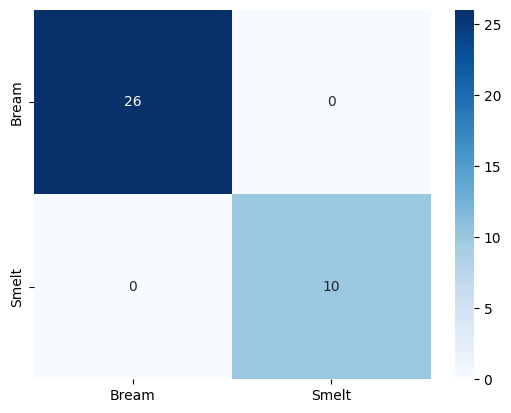

In [32]:
sns.heatmap(data=train_cm, cmap='Blues', annot=True,
            xticklabels=target_names, yticklabels=target_names)
plt.show()

### 테스트 셋 평가

In [34]:
test_pred = pipe.predict(X=x_test)  # 테스트 셋 (도미/빙어) 예측값

In [35]:
print(test_pred)

['Bream' 'Bream' 'Bream' 'Smelt' 'Smelt' 'Bream' 'Smelt' 'Bream' 'Smelt'
 'Bream' 'Bream' 'Bream' 'Bream']


In [36]:
print(y_test)

['Bream' 'Bream' 'Bream' 'Smelt' 'Smelt' 'Bream' 'Smelt' 'Bream' 'Smelt'
 'Bream' 'Bream' 'Bream' 'Bream']


In [37]:
test_report = classification_report(y_true=y_test, y_pred=test_pred)
print(test_report)

              precision    recall  f1-score   support

       Bream       1.00      1.00      1.00         9
       Smelt       1.00      1.00      1.00         4

    accuracy                           1.00        13
   macro avg       1.00      1.00      1.00        13
weighted avg       1.00      1.00      1.00        13



In [38]:
test_cm = confusion_matrix(y_true=y_test, y_pred=test_pred)
print(test_cm)

[[9 0]
 [0 4]]


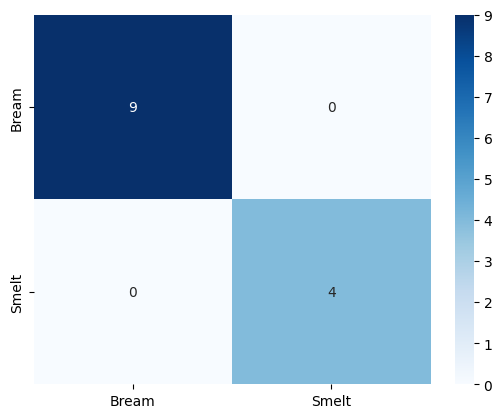

In [39]:
sns.heatmap(data=test_cm, cmap='Blues', annot=True,
            xticklabels=target_names, yticklabels=target_names)
plt.show()

# LogisticRegression의 분류 과정

In [42]:
train_pred_pr = pipe.predict_proba(X=x_train)  # 훈련 셋 예측(도미 vs 빙어) 확률
print(train_pred_pr[:5])

[[0.99729033 0.00270967]
 [0.95896655 0.04103345]
 [0.04270989 0.95729011]
 [0.98408167 0.01591833]
 [0.04237554 0.95762446]]


In [43]:
train_pred_pr.shape  #> (36, 2) = (n_samples, n_probabilities)

(36, 2)

Logistic Regression 이진 분류(binary-class classification) 원리

*   데이터를 학습하면서 선형 회귀식을 찾음.
    *   분류 문제의 손실(비용) 함수를 최소로 하는 계수들과 절편을 찾음.
*   회귀 방정식으로 계산된 결과를 로지스틱 함수(시그모이드 함수)의 아규먼트로 전달
    *   로지스틱 함수의 리턴 값은 항상 0 ~ 1
    *   로지스틱 함수의 리턴 값을 양성이 될 확률(p)로 해석.
    *   음성이 될 확률은 1 - p.